# Get CO2 emissions from GFED4.1s
 * Notebook formulated after the CO example in GFED folder

In [1]:
import xarray as xr
import os
import pandas as pd
import numpy as np
from tqdm import tqdm

In [2]:
def select_area(aoi, ds):
    # Determine the dimension names for latitude and longitude
    lat_name = 'lat' if 'lat' in ds.dims else 'latitude'
    lon_name = 'lon' if 'lon' in ds.dims else 'longitude'
    
    # Select the area based on the area of interest
    area_subset = ds.sel({lon_name: slice(aoi[0], aoi[1]),
                          lat_name: slice(aoi[2], aoi[3])})
    return area_subset

def hours_in_months(year):
    """
    Calculate the number of hours in each month of a given year,
    taking into account leap years.

    Args:
        year (int): The year to calculate the hours for.

    Returns:
        an array with hours in each month of the year
    """
    import calendar

 
    # Get the number of days in each month of the year. Note that monthrange counts months from 1 to 12, 
    # and takes leap years into account.
    days_in_month = [calendar.monthrange(year, month)[1] for month in range(1, 13)]

    # Calculate hours for each month
    hours_per_month = [days_in_month[i] * 24 for i in range(12)]

    return np.array(hours_per_month)

In [72]:

import h5py # if this creates an error please make sure you have the h5py library

varname = 'co2_fire'
newlon = np.arange(-179.0, 180.0, 2)
newlat = np.arange(-89.0, 90.0, 2)

months       = '01','02','03','04','05','06','07','08','09','10','11','12'
sources      = 'SAVA','BORF','TEMF','DEFO','PEAT','AGRI'



directory    = '/home/pietaril/Documents/data/GFED4.1s/rawdata'
OUTPATH = "/home/pietaril/Documents/data/GFED4.1s/2X2_monthly"


"""
Read in emission factors
"""
species = [] # names of the different gas and aerosol species
EFs     = np.zeros((41, 6)) # 41 species, 6 sources

k = 0
f = open(directory+'/ancill/GFED4_Emission_Factors.txt')
while 1:
    line = f.readline()
    if line == "":
        break
        
    if line[0] != '#':
        contents = line.split()
        species.append(contents[0])
        EFs[k,:] = contents[1:]
        k += 1
                
f.close()

# we are interested in CO2 for this example (3th row):
EF_CO2 = EFs[2,:]

start_year = 2017
end_year   = 2023





for year in tqdm(range(start_year, end_year+1)):
    string = directory+'/GFED4.1s_'+str(year)+'_beta.hdf5'
    f = h5py.File(string, 'r')
    
    
    if year == start_year: # these are time invariable    
       
        latitudes = f['lat'][:]
        #unique automatically sorts the values, and need to reverse the order of latitudes so that
        # it matches how the data is organized
        latitudes = np.unique(latitudes).astype('float64')[::-1]
        longitudes = f['lon'][:]
        longitudes = np.unique(longitudes).astype('float64')
        
    
    
    monthly_datas =[]
    for month in range(12):
        CO2_emissions = np.zeros((720, 1440))
        # read in DM emissions
        string = '/emissions/'+months[month]+'/DM'
        DM_emissions = f[string][:]
        for source in range(6):
            # read in the fractional contribution of each source
            string = '/emissions/'+months[month]+'/partitioning/DM_'+sources[source]
            contribution = f[string][:]
            # calculate CO2 emissions as the product of DM emissions (kg DM per 
            # m2 per month), the fraction the specific source contributes to 
            # this (unitless), and the emission factor (g CO2 per kg DM burned)
            CO2_emissions += DM_emissions * contribution * EF_CO2[source]
        da = xr.DataArray(CO2_emissions, dims=('latitude', 'longitude'), coords={'latitude':latitudes, 'longitude':longitudes})
        da = da.expand_dims({'time':pd.to_datetime([f"{year}-{month+1}-01"])})
        monthly_datas.append(da)


    da = xr.concat(monthly_datas, 'time')
    da = da.sortby('latitude')
    
    #regrid to 2 x 2
    da = da.interp({'latitude':newlat, 'longitude':newlon})
    
    #per month to per hour
    da = da.sortby('time')
    hours_per_month = hours_in_months(year)
    da = da/hours_per_month.reshape((12,1,1))
    #g to kg
    da = da/1e3
    da.name= varname

    da = da.to_dataset()
    da[varname].attrs.update({'units': "kg(CO2) m-2 hr-1"})
    da.attrs.update({'description': 'Global CO2 fire emissions from GFED4.1s, all sources, interpolated to 2X2 deg spatial resolution '})
    fname = f"GFED4.1_global_CO2_emi_2X2_monthly_{year}.nc"
    da.to_netcdf(os.path.join(OUTPATH,fname), encoding={'time':{'units': "days since 1900-01-01", 'dtype':'float64'}, varname: {'dtype': 'float64'}})


    


100%|██████████| 7/7 [00:05<00:00,  1.23it/s]


In [4]:
OUTPATH = "/home/pietaril/Documents/data/GFED4.1s/2X2_monthly"
fnames = [os.path.join(OUTPATH, f) for f in os.listdir(OUTPATH)]
fnames.sort()

ds = xr.open_dataset(fnames[3])
ds

<xarray.Dataset>
Dimensions:    (time: 12, latitude: 90, longitude: 180)
Coordinates:
  * time       (time) datetime64[ns] 2020-01-01 2020-02-01 ... 2020-12-01
  * latitude   (latitude) float64 -89.0 -87.0 -85.0 -83.0 ... 85.0 87.0 89.0
  * longitude  (longitude) float64 -179.0 -177.0 -175.0 ... 175.0 177.0 179.0
Data variables:
    co2_fire   (time, latitude, longitude) float64 ...
Attributes:
    description:  Global CO2 fire emissions from GFED4.1s, all sources, inter...

In [ ]:
   
basis_regions = f['/ancill/basis_regions'][:]
grid_area     = f['/ancill/grid_cell_area'][:]

 # fill table with total values for the globe (row 15) or basisregion (1-14)
#     for region in range(15):
#         if region == 14:
#             mask = np.ones((720, 1440))
#         else:
#             mask = basis_regions == (region + 1)            
    
#         CO2_table[region, year-start_year] = np.sum(grid_area * mask * CO2_emissions)
        
#     print(year)
        
# # convert to Tg CO2 
# CO2_table = CO2_table / 1E12
# CO2_table

# please compare this to http://www.falw.vu/~gwerf/GFED/GFED4/tables/GFED4.1s_CO.txt

In [59]:
EF_CO2

array([1686., 1489., 1647., 1643., 1703., 1585.])

In [5]:

import matplotlib.pyplot as plt
import matplotlib as mpl
import cartopy.crs as ccrs

def plot_fluxes(ds, variable, ncols, cmap, cbar_label, suptitle=None):
    # Sample data from your dataset (replace 'ds_allyears' and 'emi_fire' with your data variables)
    data = ds[variable]

    # Define colorbar shrink parameter
    cbar_shrink = 0.7

    # Create the plot
    g = data.plot.pcolormesh(
        x="longitude",
        y="latitude",
        col="time",
        col_wrap=ncols,
        robust=True,
        aspect=1.25,
        cmap=cmap,
        subplot_kws=dict(projection=ccrs.PlateCarree()),
        cbar_kwargs=dict(label=cbar_label, shrink=cbar_shrink),
    )

    # Calculate the total number of subplots (including blanks)
    nplots = len(data.time)  # Total number of time slices
    nrows = (nplots + ncols - 1) // ncols  # Calculate number of rows (rounding up)

    # Adjust axes to handle blank spaces correctly
    for i, ax in enumerate(g.axes.flat):
        if i < nplots:  # Plot only for valid time slices
            time = str(data.time.values[i])[0:8]
            ax.set_title(time)
            ax.coastlines()
        else:  # Completely remove unused subplots
            g.fig.delaxes(ax)

    # Adjust the suptitle to account for the colorbar space
    # Compute the amount to shift the title leftward
    colorbar_offset = (1 - cbar_shrink) / 2  # Fraction of the figure width
    title_x_adjustment = colorbar_offset * g.fig.get_figwidth()

    # Add the suptitle and position it
    if not suptitle==None:
        g.fig.suptitle(
            suptitle,
            fontsize=18,
            x=0.5 - title_x_adjustment / g.fig.get_figwidth(),  # Centered and adjusted left
            y=0.9,  
        )

    # Adjust the spacing
    g.fig.subplots_adjust(top=0.85, right=0.8, wspace=0.1, hspace=0.1)

    # Draw the plot
    plt.draw()

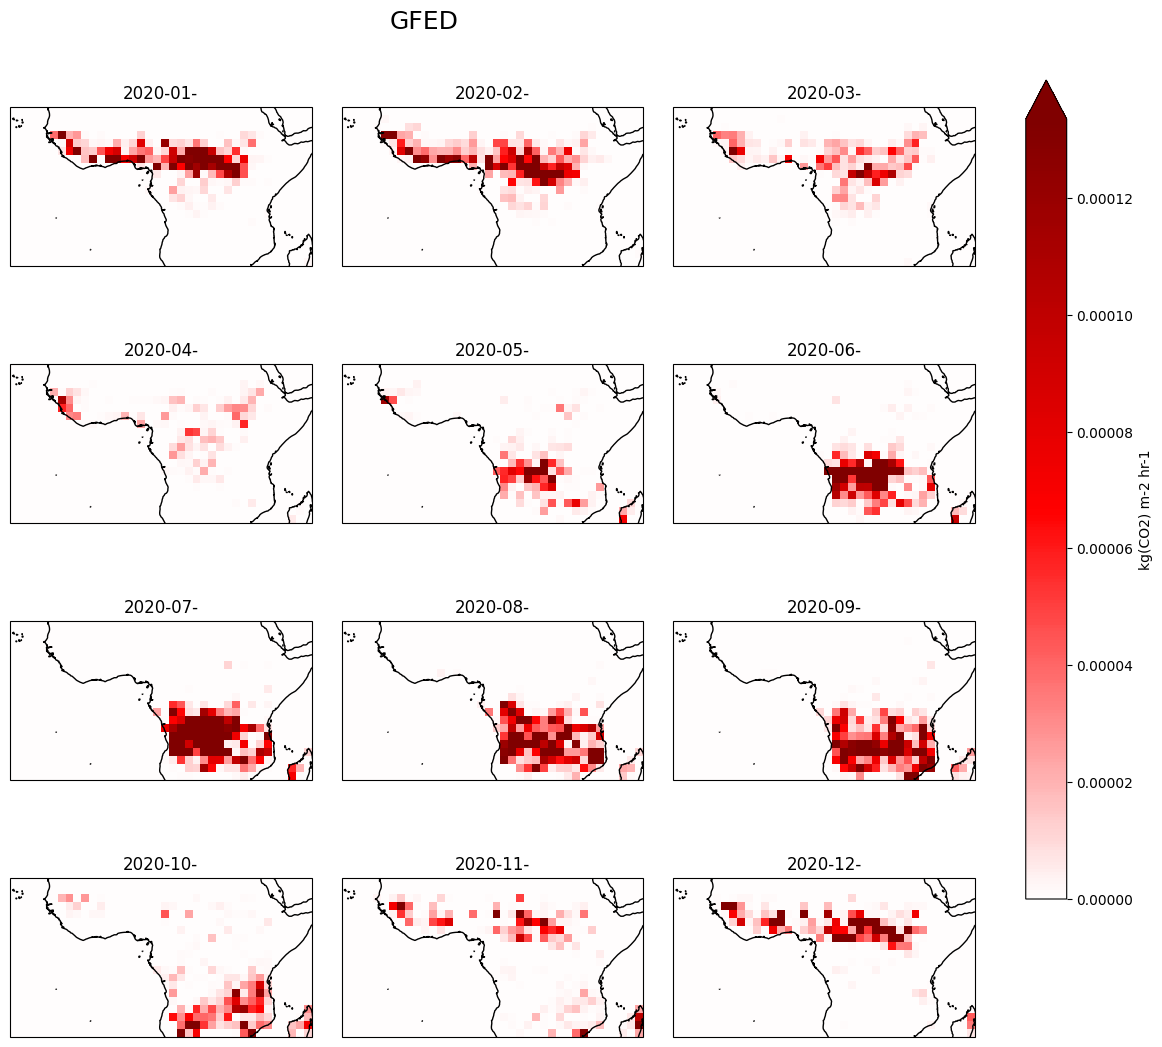

In [6]:
from truncate_colormap import truncate_colormap
cmap = truncate_colormap(mpl.colormaps["seismic"], minval=0.5)
aoi = [-25, 50, -20, 20]
ds = select_area(aoi, ds)
#cmap = mpl.colormaps["seismic"]

plot_fluxes(ds, "co2_fire", 3, cmap, "kg(CO2) m-2 hr-1" , "GFED")

In [ ]:
# Compare to GFAS



In [15]:
string = directory+'/GFED4.1s_'+str(2017)+'_beta.hdf5'
    
f = h5py.File(string, 'r')
list(f.keys())

['ancill', 'emissions', 'lat', 'lon']

In [33]:
f['emissions']['01']['DM']

<HDF5 dataset "DM": shape (720, 1440), type "<f4">

In [36]:
latitudes

array([ 89.875,  89.625,  89.375,  89.125,  88.875,  88.625,  88.375,
        88.125,  87.875,  87.625,  87.375,  87.125,  86.875,  86.625,
        86.375,  86.125,  85.875,  85.625,  85.375,  85.125,  84.875,
        84.625,  84.375,  84.125,  83.875,  83.625,  83.375,  83.125,
        82.875,  82.625,  82.375,  82.125,  81.875,  81.625,  81.375,
        81.125,  80.875,  80.625,  80.375,  80.125,  79.875,  79.625,
        79.375,  79.125,  78.875,  78.625,  78.375,  78.125,  77.875,
        77.625,  77.375,  77.125,  76.875,  76.625,  76.375,  76.125,
        75.875,  75.625,  75.375,  75.125,  74.875,  74.625,  74.375,
        74.125,  73.875,  73.625,  73.375,  73.125,  72.875,  72.625,
        72.375,  72.125,  71.875,  71.625,  71.375,  71.125,  70.875,
        70.625,  70.375,  70.125,  69.875,  69.625,  69.375,  69.125,
        68.875,  68.625,  68.375,  68.125,  67.875,  67.625,  67.375,
        67.125,  66.875,  66.625,  66.375,  66.125,  65.875,  65.625,
        65.375,  65.

In [26]:
longitudes

array([-179.875, -179.625, -179.375, ...,  179.375,  179.625,  179.875])

In [18]:
f['lat'][:]

array([[ 89.875,  89.875,  89.875, ...,  89.875,  89.875,  89.875],
       [ 89.625,  89.625,  89.625, ...,  89.625,  89.625,  89.625],
       [ 89.375,  89.375,  89.375, ...,  89.375,  89.375,  89.375],
       ...,
       [-89.375, -89.375, -89.375, ..., -89.375, -89.375, -89.375],
       [-89.625, -89.625, -89.625, ..., -89.625, -89.625, -89.625],
       [-89.875, -89.875, -89.875, ..., -89.875, -89.875, -89.875]],
      dtype=float32)

In [27]:
f['lon'][:]

array([[-179.875, -179.625, -179.375, ...,  179.375,  179.625,  179.875],
       [-179.875, -179.625, -179.375, ...,  179.375,  179.625,  179.875],
       [-179.875, -179.625, -179.375, ...,  179.375,  179.625,  179.875],
       ...,
       [-179.875, -179.625, -179.375, ...,  179.375,  179.625,  179.875],
       [-179.875, -179.625, -179.375, ...,  179.375,  179.625,  179.875],
       [-179.875, -179.625, -179.375, ...,  179.375,  179.625,  179.875]],
      dtype=float32)

In [8]:
CO2_emissions.shape

(720, 1440)